## Introduction

This analysis is part of a civic technology research project aimed at uncovering data-driven insights to support better decision-making in public safety and justice.

As a data analyst supporting the research team, my objective is to curate, clean, and analyze relevant secondary datasets that provide meaningful insights into crime trends. These insights can guide policymakers, civic tech developers, and community organizations in crafting data-informed interventions to improve public well-being.

The dataset used in this project focuses on crime statistics (crimes reported to the police) across in Kenya in the years 2008-2017, providing a lens into the state of civic security and enforcement patterns over time.

### Curating a credible secondary dataset

To support the research on civic technology, I identified credible secondary data from openAfrica.
openAFRICA is not a government portal. Instead, it’s a grassroots initiative, maintained by Code for Africa, as a public service. The platform is available as a free resource for ordinary citizens, civil society organisations, civic activists, the media, and government agencies.
The data extracted here is credible because its source is the Kenya Bureau of Statistics (KNBS).

The chosen dataset contains crime statistics reported to the police, which aligns with civic concerns like safety and justice system performance.

Dataset URL: https://open.africa/dataset/9a9c52b6-65f6-4483-890f-3a34bb164ce2/resource/69239d4c-abe9-4213-8035-29ae0607b721/download/crimes-reported-to-the-police-2008-2017.csv

Crimes Reported to the Police, 2008 - 2017, Statistical Abstract, 2018, https://www.knbs.or.ke/download/statistics-abstract-2018/





### Information about the dataset

The dataset contains data on crimes reported to the police between 2008 and 2017 in Kenya. The key columns in the dataset are as follows:

- geo_level: The level of geographic detail (e.g., "country").

- geo_code: The code representing the geographical region.

- name: the name of the geographic location (in this case, it's Kenya)

- year: The year the crime data is recorded.

- crimes: The specific type of crime (e.g., "Breakings," "Corruption").

- total: The number of occurrences of that crime in the given year.

### Loading the data

The dataset was downloaded in CSV format and loaded using pandas.

In [1]:
import pandas as pd

# Load the dataset
file_path = 'crimes-reported-to-the-police-2008-2017.csv'
data = pd.read_csv(file_path)

# Display the first few rows of the dataset
data.head()

,geo_level,geo_code,geo_version,name,year,crimes,total
0,country,KE,NaN,Kenya,2008,Breakings,6626
1,country,KE,NaN,Kenya,2008,Corruption,133
2,country,KE,NaN,Kenya,2008,Criminal damage,3760
3,country,KE,NaN,Kenya,2008,Dangerous drugs,4407
4,country,KE,NaN,Kenya,2008,Economic crimes,1898


### Inspecting the data

In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   geo_level    180 non-null    object 
 1   geo_code     180 non-null    object 
 2   geo_version  0 non-null      float64
 3   name         180 non-null    object 
 4   year         180 non-null    int64  
 5   crimes       180 non-null    object 
 6   total        180 non-null    int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 10.0+ KB


### Cleaning and preparing the data for analysis

The dataset was cleaned by removing duplicates and irrelevant columns. Data types were also standardized for analysis readiness.

In [3]:
duplicates = data.duplicated().sum()
duplicates

0

In [4]:
data_cleaned = data.drop(columns=['geo_version'])

# Ensure that 'year' and 'total' are of correct data types
data_cleaned['year'] = data_cleaned['year'].astype(int)
data_cleaned['total'] = data_cleaned['total'].astype(int)
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   geo_level  180 non-null    object
 1   geo_code   180 non-null    object
 2   name       180 non-null    object
 3   year       180 non-null    int32 
 4   crimes     180 non-null    object
 5   total      180 non-null    int32 
dtypes: int32(2), object(4)
memory usage: 7.2+ KB


### Analysing the data and drawing insights

Using grouped analysis and simple aggregation, I identified patterns in crime rates across years. I used a visualization to uncover key insights.


In [7]:
crime_trends = data_cleaned.groupby(['year', 'crimes'])['total'].sum().reset_index()

# Pivot the data for a better visualization of trends over the years
crime_trends_pivot = crime_trends.pivot(index='year', columns='crimes', values='total').fillna(0)

cols = crime_trends_pivot.columns.tolist()

# Move 'Total' to the end
if 'Total' in cols:
    cols.remove('Total')     # Remove it from its current position
    cols.append('Total')     # Append it to the end

# Reorder the DataFrame columns
crime_trends_pivot = crime_trends_pivot[cols]

# Display the last few rows to get a sense of the trends
crime_trends_pivot.tail(5)


crimes,Breakings,Corruption,Criminal damage,Dangerous drugs,Economic crimes,Homicide,Offences against morality,Offences involving police officers,Offences involving tourists,Other offences against persons,Other penal code offences,Robbery,Stealing,Theft by servant,Theft of stock,Traffic offences,Vehicles and other thefts,Total
year,,,,,,,,,,,,,,,,,,
2013,6397,57,3603,4316,2750,2878,4779,95,14,19344,6250,3551,11455,2702,1965,45,1631,71832
2014,5656,138,3709,4850,3038,2649,5184,53,21,19911,5648,3011,10042,2279,1848,100,1239,69376
2015,5591,79,3983,5525,3244,2648,6164,71,19,21174,6223,2865,9528,2184,1961,120,1111,72490
2016,5621,92,4307,6160,3503,2751,6228,57,15,22295,7047,2697,10361,2440,1918,139,1355,76986
2017,6131,75,4262,5565,3695,2774,5492,86,15,22515,6772,2713,11656,2632,2136,69,1404,77992


Some insights that can be drawn from the table are:

1. Breakings and Robbery are consistently among the highest reported crime types.
2. Corruption appears to have relatively low numbers compared to other crime categories.
3. There are fluctuating trends in crimes like Homicide, Economic crimes, and Theft over the years.
4. Traffic offenses seem relatively low compared to other crime categories.

<Figure size 1400x800 with 0 Axes>

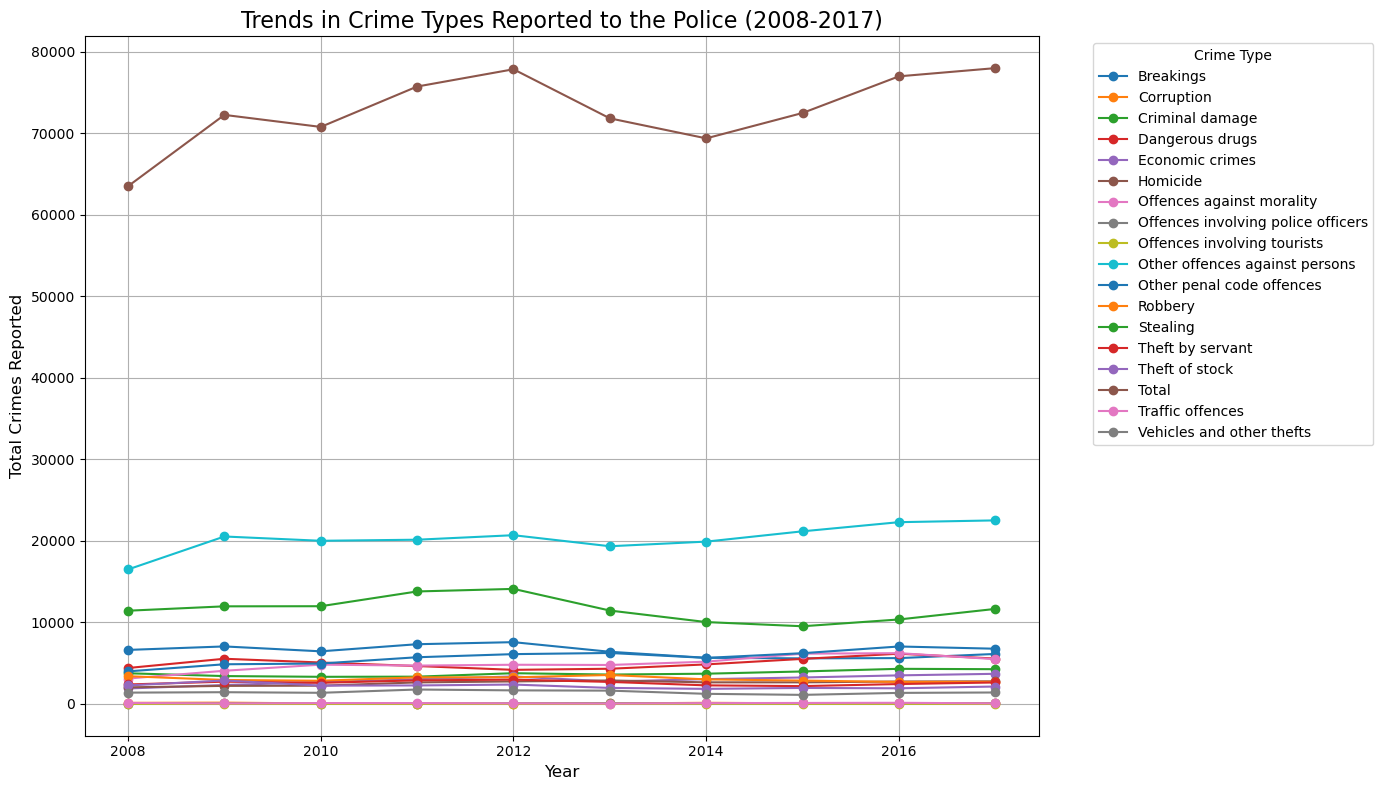

In [6]:
import matplotlib.pyplot as plt

# Plot the trends for all crime categories over the years
plt.figure(figsize=(14, 8))
crime_trends_pivot.plot(kind='line', marker='o', linestyle='-', figsize=(14, 8))

plt.title("Trends in Crime Types Reported to the Police (2008-2017)", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Crimes Reported", fontsize=12)
plt.legend(title="Crime Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()


#### Observations

1. Breakings consistently have high crime counts, with an overall upward trend over the years.
2. Robbery also shows a general increase in reported cases over time, though it experiences some fluctuation.
3. Traffic offenses and Corruption remain relatively low compared to other crime types, though there are small fluctuations.
4. Homicide, Economic crimes, and Theft also follow increasing or fluctuating patterns, indicating potential areas for further investigation or intervention.
